# NER Results Analysis — decicontas.br

This notebook loads all checkpoint DataFrames, computes token-level and span-level metrics, and provides comparative insights across models and strategies.

In [1]:
import os
import pickle
import warnings
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import defaultdict
from rapidfuzz import fuzz
from sklearn.metrics import precision_recall_fscore_support

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Metric Functions

In [2]:
DICT_LABELS = {
    "obrigacoes": "OBRIGACAO",
    "recomendacoes": "RECOMENDACAO",
    "ressarcimentos": "RESSARCIMENTO",
    "multas": "MULTA",
}

def convert_pred_to_golden_format(row, window_size=500, step_size=100, min_score=80):
    pred_spans = []
    text = row['text']
    pred = row['pred']
    for label_type, spans in pred.items():
        for span in (spans or []):
            if not isinstance(span, dict):
                continue
            span_text = (
                span.get("descricao_multa") or span.get("descricao_obrigacao")
                or span.get("descricao_ressarcimento") or span.get("descricao_recomendacao")
            )
            if not span_text:
                continue
            best_score, best_pos, best_substring = 0, -1, ""
            for start in range(0, len(text), step_size):
                window = text[start:start+window_size]
                score = fuzz.partial_ratio(span_text, window)
                if score > best_score and score >= min_score:
                    best_score = score
                    best_pos = start + window.find(span_text.split()[0]) if span_text.split() else start
                    best_substring = span_text
            if best_score >= min_score and best_pos >= 0:
                pred_spans.append({
                    "start": best_pos, "end": best_pos + len(best_substring),
                    "text": best_substring, "labels": [DICT_LABELS[label_type]]
                })
    return pred_spans

def _strip_bio(tag):
    if tag == 'O' or tag is None: return 'O'
    parts = tag.split('-', 1)
    return parts[1] if len(parts) == 2 else parts[0]

def compute_iou_score(span_a, span_b, label_a, label_b, threshold=0.5):
    s_a, e_a = span_a
    s_b, e_b = span_b
    if e_a <= s_b or e_b <= s_a: return 0.0
    intersection = max(0, min(e_a, e_b) - max(s_a, s_b))
    union = max(e_a, e_b) - min(s_a, s_b)
    iou = intersection / union if union > 0 else 0.0
    return 1.0 if (iou >= threshold and label_a == label_b) else 0.0

def calculate_metrics(df, iou_threshold=0.5, spacy_model="pt_core_news_sm"):
    nlp = spacy.load(spacy_model)
    y_true_tokens, y_pred_tokens = [], []
    label_metrics = defaultdict(lambda: {"total_gold": 0, "total_pred": 0, "matched": 0})

    for _, row in df.iterrows():
        text = row["text"]
        doc = nlp(text)
        true_bio = ['O'] * len(doc)
        pred_bio = ['O'] * len(doc)

        for ann in row.get("golden", []):
            start, end, label = ann["start"], ann["end"], ann["labels"][0]
            cs = doc.char_span(start, end, label=label, alignment_mode="expand")
            if cs:
                for j, tok in enumerate(cs):
                    true_bio[tok.i] = f"B-{label}" if j == 0 else f"I-{label}"

        for ann in row.get("pred_as_golden", []):
            start, end, label = ann["start"], ann["end"], ann["labels"][0]
            cs = doc.char_span(start, end, label=label, alignment_mode="expand")
            if cs:
                for j, tok in enumerate(cs):
                    pred_bio[tok.i] = f"B-{label}" if j == 0 else f"I-{label}"

        y_true_tokens.append([_strip_bio(t) for t in true_bio])
        y_pred_tokens.append([_strip_bio(t) for t in pred_bio])

        gold_spans = [(a['start'], a['end'], a['labels'][0]) for a in row.get('golden', [])]
        pred_spans = [(a['start'], a['end'], a['labels'][0]) for a in row.get('pred_as_golden', [])]
        for _, _, lab in gold_spans: label_metrics[lab]["total_gold"] += 1
        for _, _, lab in pred_spans: label_metrics[lab]["total_pred"] += 1

        matched_pairs = set()
        for pi, p in enumerate(pred_spans):
            for gi, g in enumerate(gold_spans):
                if (pi, gi) in matched_pairs: continue
                if compute_iou_score((p[0], p[1]), (g[0], g[1]), p[2], g[2], threshold=iou_threshold) > 0:
                    label_metrics[p[2]]["matched"] += 1
                    matched_pairs.add((pi, gi))
                    break

    flat_true, flat_pred = [], []
    for t_seq, p_seq in zip(y_true_tokens, y_pred_tokens):
        for t, p in zip(t_seq, p_seq):
            if t != 'O' or p != 'O':
                flat_true.append(t)
                flat_pred.append(p)

    if not flat_true:
        token_prec = token_rec = token_f1 = 0.0
        per_label = {}
    else:
        labels_sorted = sorted(set(l for l in flat_true + flat_pred if l != 'O'))
        token_prec, token_rec, token_f1, _ = precision_recall_fscore_support(
            flat_true, flat_pred, labels=labels_sorted, average='micro', zero_division=0)
        prec_l, rec_l, f1_l, sup_l = precision_recall_fscore_support(
            flat_true, flat_pred, labels=labels_sorted, average=None, zero_division=0)
        per_label = {lab: {"precision": float(p), "recall": float(r), "f1": float(f), "support": int(s)}
                     for lab, p, r, f, s in zip(labels_sorted, prec_l, rec_l, f1_l, sup_l)}

    total_gold = sum(v["total_gold"] for v in label_metrics.values())
    total_pred = sum(v["total_pred"] for v in label_metrics.values())
    total_matched = sum(v["matched"] for v in label_metrics.values())
    iou_prec = total_matched / total_pred if total_pred > 0 else 0.0
    iou_rec = total_matched / total_gold if total_gold > 0 else 0.0
    iou_f1 = (2 * iou_prec * iou_rec / (iou_prec + iou_rec)) if (iou_prec + iou_rec) > 0 else 0.0

    iou_per_label = {}
    for label, m in label_metrics.items():
        prec = m["matched"] / m["total_pred"] if m["total_pred"] > 0 else 0.0
        rec = m["matched"] / m["total_gold"] if m["total_gold"] > 0 else 0.0
        f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0
        iou_per_label[label] = {"precision": prec, "recall": rec, "f1": f1,
                                 "matched": m["matched"], "total_pred": m["total_pred"], "total_gold": m["total_gold"]}

    return {
        "token_flat": {"precision": token_prec, "recall": token_rec, "f1": token_f1, "per_label": per_label},
        "iou_agg": {"precision": iou_prec, "recall": iou_rec, "f1": iou_f1},
        "iou_per_label": iou_per_label,
    }

def evaluate_results(df_results):
    df_results['pred_as_golden'] = df_results.apply(
        lambda row: convert_pred_to_golden_format(row, window_size=500, step_size=100, min_score=80), axis=1)
    raw = calculate_metrics(df_results, iou_threshold=0.5)
    metrics = {
        "token_precision": raw["token_flat"]["precision"],
        "token_recall": raw["token_flat"]["recall"],
        "token_f1": raw["token_flat"]["f1"],
        "span_precision": raw["iou_agg"]["precision"],
        "span_recall": raw["iou_agg"]["recall"],
        "span_f1": raw["iou_agg"]["f1"],
    }
    for label, vals in raw["iou_per_label"].items():
        metrics[f"f1_{label}"] = vals["f1"]
        metrics[f"precision_{label}"] = vals["precision"]
        metrics[f"recall_{label}"] = vals["recall"]
    return metrics, raw

print('Metric functions loaded.')

Metric functions loaded.


## 2. Load Checkpoints & Compute Metrics

In [3]:
CHECKPOINTS_DIR = Path('dataset/results/checkpoints/')

all_results = {}
all_raw = {}

pkl_files = sorted(CHECKPOINTS_DIR.glob('*.pkl'))
print(f'Found {len(pkl_files)} checkpoints:\n')
for f in pkl_files:
    print(f'  {f.name}')

Found 28 checkpoints:

  bilstm-crf__supervised.pkl
  bilstm_crf__supervised.pkl
  deepseek-v3__few_shot.pkl
  deepseek-v3__self_refinement.pkl
  deepseek-v3__two_stage.pkl
  gemini-2-5-flash__dynamic_few_shot.pkl
  gemini-2-5-flash__few_shot.pkl
  gemini-2-5-flash__self_refinement.pkl
  gemini-2-5-flash__two_stage.pkl
  gemini-2-5-pro__few_shot.pkl
  gpt-35-turbo__few_shot.pkl
  gpt-4o__few_shot.pkl
  gpt-5-4-mini__dynamic_few_shot.pkl
  gpt-5-4-mini__few_shot.pkl
  gpt-5-4-mini__self_refinement.pkl
  gpt-5-4-mini__two_stage.pkl
  gpt-5-4-nano__dynamic_few_shot.pkl
  gpt-5-4-nano__few_shot.pkl
  gpt-5-4-nano__self_refinement.pkl
  gpt-5-4-nano__two_stage.pkl
  gpt-5-4__few_shot.pkl
  llama-4-maverick__few_shot.pkl
  mistral-small-3-2__dynamic_few_shot.pkl
  mistral-small-3-2__few_shot.pkl
  neuralmind_bert-base-portuguese-cased__supervised.pkl
  neuralmind_bert-large-portuguese-cased__supervised.pkl
  qwen3-235b__few_shot.pkl
  rufimelo_Legal-BERTimbau-base__supervised.pkl


In [4]:
def is_bio_format(df):
    """Detect if a DataFrame stores BIO tags directly (supervised format).
    These have numeric columns and cells containing BIO tags like 'O', 'B-MULTA', etc."""
    if 'text' in df.columns or 'pred' in df.columns:
        return False
    # Check first non-NaN value in column 0
    if 0 in df.columns:
        sample = df[0].dropna().iloc[0] if len(df[0].dropna()) > 0 else None
        if isinstance(sample, str) and (sample == 'O' or sample.startswith('B-') or sample.startswith('I-')):
            return True
    return False

def evaluate_bio_format(df_pred, df_gold):
    """Compute token-level and span-level metrics for BIO-format DataFrames.
    Both DataFrames have rows=documents, columns=token indices, values=BIO tags."""
    assert len(df_pred) == len(df_gold), f'Row count mismatch: pred={len(df_pred)} gold={len(df_gold)}'
    
    flat_true, flat_pred = [], []
    label_metrics = defaultdict(lambda: {'total_gold': 0, 'total_pred': 0, 'matched': 0})
    
    for i in range(len(df_pred)):
        pred_row = df_pred.iloc[i].dropna().tolist()
        gold_row = df_gold.iloc[i].dropna().tolist()
        
        # Align to shortest length
        min_len = min(len(pred_row), len(gold_row))
        pred_tags = [str(t) for t in pred_row[:min_len]]
        gold_tags = [str(t) for t in gold_row[:min_len]]
        
        # Token-level (strip BIO prefix)
        for t, p in zip(gold_tags, pred_tags):
            tl = _strip_bio(t)
            pl = _strip_bio(p)
            if tl != 'O' or pl != 'O':
                flat_true.append(tl)
                flat_pred.append(pl)
        
        # Extract spans from BIO sequences for IoU
        def extract_spans(tags):
            spans = []
            start, label = None, None
            for j, tag in enumerate(tags):
                if tag.startswith('B-'):
                    if start is not None:
                        spans.append((start, j, label))
                    label = tag[2:]
                    start = j
                elif tag.startswith('I-') and start is not None and tag[2:] == label:
                    continue
                else:
                    if start is not None:
                        spans.append((start, j, label))
                        start, label = None, None
            if start is not None:
                spans.append((start, len(tags), label))
            return spans
        
        gold_spans = extract_spans(gold_tags)
        pred_spans = extract_spans(pred_tags)
        
        for _, _, lab in gold_spans: label_metrics[lab]['total_gold'] += 1
        for _, _, lab in pred_spans: label_metrics[lab]['total_pred'] += 1
        
        matched_pairs = set()
        for pi, p in enumerate(pred_spans):
            for gi, g in enumerate(gold_spans):
                if (pi, gi) in matched_pairs: continue
                if compute_iou_score((p[0], p[1]), (g[0], g[1]), p[2], g[2], threshold=0.5) > 0:
                    label_metrics[p[2]]['matched'] += 1
                    matched_pairs.add((pi, gi))
                    break
    
    # Token metrics
    if not flat_true:
        token_prec = token_rec = token_f1 = 0.0
    else:
        labels_sorted = sorted(set(l for l in flat_true + flat_pred if l != 'O'))
        token_prec, token_rec, token_f1, _ = precision_recall_fscore_support(
            flat_true, flat_pred, labels=labels_sorted, average='micro', zero_division=0)
    
    # Span metrics
    total_gold = sum(v['total_gold'] for v in label_metrics.values())
    total_pred = sum(v['total_pred'] for v in label_metrics.values())
    total_matched = sum(v['matched'] for v in label_metrics.values())
    iou_prec = total_matched / total_pred if total_pred > 0 else 0.0
    iou_rec = total_matched / total_gold if total_gold > 0 else 0.0
    iou_f1 = (2 * iou_prec * iou_rec / (iou_prec + iou_rec)) if (iou_prec + iou_rec) > 0 else 0.0
    
    metrics = {
        'token_precision': float(token_prec), 'token_recall': float(token_rec), 'token_f1': float(token_f1),
        'span_precision': iou_prec, 'span_recall': iou_rec, 'span_f1': iou_f1,
    }
    for label, m in label_metrics.items():
        prec = m['matched'] / m['total_pred'] if m['total_pred'] > 0 else 0.0
        rec = m['matched'] / m['total_gold'] if m['total_gold'] > 0 else 0.0
        f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) > 0 else 0.0
        metrics[f'f1_{label}'] = f1
        metrics[f'precision_{label}'] = prec
        metrics[f'recall_{label}'] = rec
    return metrics

# --- Load all checkpoints and detect formats ---
bio_checkpoints = {}   # name -> {'true_labels': [...], 'pred_labels': [...]}
llm_checkpoints = {}   # name -> DataFrame (text/pred/golden format)

for pkl_path in pkl_files:
    name = pkl_path.stem
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    
    # Dict with true_labels/pred_labels (supervised models)
    if isinstance(data, dict) and 'true_labels' in data and 'pred_labels' in data:
        bio_checkpoints[name] = data
        print(f'  {name}: BIO dict ({len(data["pred_labels"])} docs)')
        continue
    
    if isinstance(data, pd.DataFrame):
        df = data
    elif isinstance(data, list):
        df = pd.DataFrame(data)
    else:
        print(f'  {name}: unsupported format {type(data)}, skipping')
        continue
    
    llm_checkpoints[name] = df
    print(f'  {name}: LLM format ({len(df)} rows)')

print(f'\nDetected {len(llm_checkpoints)} LLM checkpoints, {len(bio_checkpoints)} BIO checkpoints.')

  bilstm-crf__supervised: BIO dict (866 docs)
  bilstm_crf__supervised: unsupported format <class 'dict'>, skipping
  deepseek-v3__few_shot: LLM format (866 rows)
  deepseek-v3__self_refinement: LLM format (866 rows)
  deepseek-v3__two_stage: LLM format (866 rows)
  gemini-2-5-flash__dynamic_few_shot: LLM format (866 rows)
  gemini-2-5-flash__few_shot: LLM format (866 rows)
  gemini-2-5-flash__self_refinement: LLM format (866 rows)
  gemini-2-5-flash__two_stage: LLM format (866 rows)
  gemini-2-5-pro__few_shot: LLM format (866 rows)
  gpt-35-turbo__few_shot: LLM format (866 rows)
  gpt-4o__few_shot: LLM format (866 rows)
  gpt-5-4-mini__dynamic_few_shot: LLM format (866 rows)
  gpt-5-4-mini__few_shot: LLM format (866 rows)
  gpt-5-4-mini__self_refinement: LLM format (866 rows)
  gpt-5-4-mini__two_stage: LLM format (866 rows)
  gpt-5-4-nano__dynamic_few_shot: LLM format (866 rows)
  gpt-5-4-nano__few_shot: LLM format (866 rows)
  gpt-5-4-nano__self_refinement: LLM format (866 rows)
  gp

In [5]:
len(llm_checkpoints['deepseek-v3__few_shot'])

866

In [6]:
# --- Process LLM checkpoints ---
print('=== LLM checkpoints ===')
for name, df in llm_checkpoints.items():
    print(f'  {name} ... ', end='')
    try:
        metrics, raw = evaluate_results(df.copy())
        all_results[name] = metrics
        all_raw[name] = raw
        print(f'token_f1={metrics["token_f1"]:.4f}  span_f1={metrics["span_f1"]:.4f}')
    except Exception as e:
        print(f'ERROR: {e}')

print(f'\nEvaluated {len(all_results)} LLM checkpoints.')

=== LLM checkpoints ===
  deepseek-v3__few_shot ... token_f1=0.6758  span_f1=0.5663
  deepseek-v3__self_refinement ... token_f1=0.5589  span_f1=0.3402
  deepseek-v3__two_stage ... token_f1=0.7589  span_f1=0.6992
  gemini-2-5-flash__dynamic_few_shot ... token_f1=0.7719  span_f1=0.7106
  gemini-2-5-flash__few_shot ... token_f1=0.7533  span_f1=0.7134
  gemini-2-5-flash__self_refinement ... token_f1=0.5836  span_f1=0.3912
  gemini-2-5-flash__two_stage ... token_f1=0.7708  span_f1=0.7318
  gemini-2-5-pro__few_shot ... token_f1=0.7803  span_f1=0.7000
  gpt-35-turbo__few_shot ... token_f1=0.7332  span_f1=0.6852
  gpt-4o__few_shot ... token_f1=0.7362  span_f1=0.6836
  gpt-5-4-mini__dynamic_few_shot ... token_f1=0.7443  span_f1=0.6837
  gpt-5-4-mini__few_shot ... token_f1=0.7526  span_f1=0.7107
  gpt-5-4-mini__self_refinement ... token_f1=0.5698  span_f1=0.3825
  gpt-5-4-mini__two_stage ... token_f1=0.7349  span_f1=0.6837
  gpt-5-4-nano__dynamic_few_shot ... token_f1=0.7376  span_f1=0.7028
  gp

In [7]:
# --- Process BIO-format supervised checkpoints ---
# These dicts contain {'true_labels': [...], 'pred_labels': [...]}.
# Gold is already included, so we evaluate directly.

if bio_checkpoints:
    print(f'=== BIO checkpoints ({len(bio_checkpoints)}) ===')
    for name, data in bio_checkpoints.items():
        print(f'  {name} ... ', end='')
        try:
            gold_seqs = data['true_labels']
            pred_seqs = data['pred_labels']
            assert len(gold_seqs) == len(pred_seqs)
            
            flat_true, flat_pred = [], []
            label_metrics = defaultdict(lambda: {'total_gold': 0, 'total_pred': 0, 'matched': 0})
            
            for gold_tags, pred_tags in zip(gold_seqs, pred_seqs):
                min_len = min(len(gold_tags), len(pred_tags))
                gt = gold_tags[:min_len]
                pt = pred_tags[:min_len]
                
                for t, p in zip(gt, pt):
                    tl, pl = _strip_bio(t), _strip_bio(p)
                    if tl != 'O' or pl != 'O':
                        flat_true.append(tl)
                        flat_pred.append(pl)
                
                # Extract spans from BIO for IoU
                def _extract_spans(tags):
                    spans, start, label = [], None, None
                    for j, tag in enumerate(tags):
                        if tag.startswith('B-'):
                            if start is not None: spans.append((start, j, label))
                            label, start = tag[2:], j
                        elif tag.startswith('I-') and start is not None and tag[2:] == label:
                            continue
                        else:
                            if start is not None: spans.append((start, j, label))
                            start, label = None, None
                    if start is not None: spans.append((start, len(tags), label))
                    return spans
                
                g_spans = _extract_spans(gt)
                p_spans = _extract_spans(pt)
                for _, _, lab in g_spans: label_metrics[lab]['total_gold'] += 1
                for _, _, lab in p_spans: label_metrics[lab]['total_pred'] += 1
                matched = set()
                for pi, p in enumerate(p_spans):
                    for gi, g in enumerate(g_spans):
                        if (pi, gi) in matched: continue
                        if compute_iou_score((p[0],p[1]),(g[0],g[1]),p[2],g[2],threshold=0.5) > 0:
                            label_metrics[p[2]]['matched'] += 1
                            matched.add((pi, gi))
                            break
            
            labels_sorted = sorted(set(l for l in flat_true + flat_pred if l != 'O'))
            token_prec, token_rec, token_f1, _ = precision_recall_fscore_support(
                flat_true, flat_pred, labels=labels_sorted, average='micro', zero_division=0)
            
            total_g = sum(v['total_gold'] for v in label_metrics.values())
            total_p = sum(v['total_pred'] for v in label_metrics.values())
            total_m = sum(v['matched'] for v in label_metrics.values())
            iou_p = total_m / total_p if total_p else 0
            iou_r = total_m / total_g if total_g else 0
            iou_f1 = (2*iou_p*iou_r/(iou_p+iou_r)) if (iou_p+iou_r) else 0
            
            metrics = {'token_precision': float(token_prec), 'token_recall': float(token_rec),
                       'token_f1': float(token_f1), 'span_precision': iou_p,
                       'span_recall': iou_r, 'span_f1': iou_f1}
            for label, m in label_metrics.items():
                pr = m['matched']/m['total_pred'] if m['total_pred'] else 0
                rc = m['matched']/m['total_gold'] if m['total_gold'] else 0
                f1 = (2*pr*rc/(pr+rc)) if (pr+rc) else 0
                metrics[f'f1_{label}'] = f1
                metrics[f'precision_{label}'] = pr
                metrics[f'recall_{label}'] = rc
            
            all_results[name] = metrics
            print(f'token_f1={token_f1:.4f}  span_f1={iou_f1:.4f}')
        except Exception as e:
            print(f'ERROR: {e}')

print(f'\nTotal evaluated: {len(all_results)}/{len(pkl_files)} checkpoints.')

=== BIO checkpoints (4) ===
  bilstm-crf__supervised ... token_f1=0.8001  span_f1=0.6440
  neuralmind_bert-base-portuguese-cased__supervised ... token_f1=0.8720  span_f1=0.6617
  neuralmind_bert-large-portuguese-cased__supervised ... token_f1=0.8587  span_f1=0.7241
  rufimelo_Legal-BERTimbau-base__supervised ... token_f1=0.8429  span_f1=0.6802

Total evaluated: 27/28 checkpoints.


## 3. Summary Table

In [8]:
all_results

{'deepseek-v3__few_shot': {'token_precision': 0.6610860016551021,
  'token_recall': 0.691250374413419,
  'token_f1': 0.6758317741804278,
  'span_precision': 0.45504840940525587,
  'span_recall': 0.7494305239179955,
  'span_f1': 0.5662650602409639,
  'f1_OBRIGACAO': 0.3976261127596439,
  'precision_OBRIGACAO': 0.3073394495412844,
  'recall_OBRIGACAO': 0.5630252100840336,
  'f1_MULTA': 0.7964601769911505,
  'precision_MULTA': 0.72,
  'recall_MULTA': 0.8910891089108911,
  'f1_RECOMENDACAO': 0.37333333333333335,
  'precision_RECOMENDACAO': 0.2485207100591716,
  'recall_RECOMENDACAO': 0.75,
  'f1_RESSARCIMENTO': 0.5405405405405406,
  'precision_RESSARCIMENTO': 0.46511627906976744,
  'recall_RESSARCIMENTO': 0.6451612903225806},
 'deepseek-v3__self_refinement': {'token_precision': 0.4687408409423966,
  'token_recall': 0.6919492794621759,
  'token_f1': 0.5588828257304911,
  'span_precision': 0.22191400832177532,
  'span_recall': 0.7289293849658315,
  'span_f1': 0.3402445507708666,
  'f1_RESSAR

In [21]:
df_metrics = pd.DataFrame(all_results).T
df_metrics.index.name = 'experiment'

# Parse model and strategy from experiment name
df_metrics['model'] = df_metrics.index.map(lambda x: x.rsplit('__', 1)[0])
df_metrics['strategy'] = df_metrics.index.map(lambda x: x.rsplit('__', 1)[1] if '__' in x else 'unknown')

# Reorder columns
main_cols = ['model', 'strategy', 'token_f1', 'token_precision', 'token_recall',
             'span_f1', 'span_precision', 'span_recall']
extra_cols = [c for c in df_metrics.columns if c not in main_cols]
df_metrics = df_metrics[main_cols + extra_cols]

df_metrics.sort_values('span_f1', ascending=False, inplace=True)
df_metrics.sort_values('span_f1', ascending=False).style.format('{:.4f}', subset=[c for c in df_metrics.columns if c not in ['model', 'strategy']]) \
    .background_gradient(cmap='YlGn', subset=['token_f1', 'span_f1'])

,model,strategy,token_f1,token_precision,token_recall,span_f1,span_precision,span_recall,f1_OBRIGACAO,precision_OBRIGACAO,recall_OBRIGACAO,f1_MULTA,precision_MULTA,recall_MULTA,f1_RECOMENDACAO,precision_RECOMENDACAO,recall_RECOMENDACAO,f1_RESSARCIMENTO,precision_RESSARCIMENTO,recall_RESSARCIMENTO
experiment,,,,,,,,,,,,,,,,,,,,
gemini-2-5-flash__two_stage,gemini-2-5-flash,two_stage,0.7708,0.7503,0.7925,0.7318,0.6507,0.8360,0.5687,0.4527,0.7647,0.8696,0.8491,0.8911,0.7273,0.5977,0.9286,0.6984,0.6875,0.7097
gpt-5-4-nano__two_stage,gpt-5-4-nano,two_stage,0.7545,0.7929,0.7196,0.7242,0.6732,0.7836,0.5878,0.5714,0.6050,0.8445,0.7948,0.9010,0.5874,0.4828,0.7500,0.7328,0.6957,0.7742
neuralmind_bert-large-portuguese-cased__supervised,neuralmind_bert-large-portuguese-cased,supervised,0.8587,0.8623,0.8553,0.7241,0.7371,0.7114,0.6804,0.7586,0.6168,0.7936,0.7749,0.8132,0.5510,0.5870,0.5192,0.7200,0.7031,0.7377
gpt-5-4-nano__few_shot,gpt-5-4-nano,few_shot,0.7479,0.7927,0.7078,0.7194,0.6699,0.7768,0.6390,0.6311,0.6471,0.8445,0.7948,0.9010,0.5493,0.4535,0.6964,0.6418,0.5972,0.6935
gemini-2-5-flash__few_shot,gemini-2-5-flash,few_shot,0.7533,0.7355,0.7721,0.7134,0.6300,0.8223,0.5732,0.4498,0.7899,0.8454,0.8255,0.8663,0.6944,0.5682,0.8929,0.6667,0.6562,0.6774
gpt-5-4-mini__few_shot,gpt-5-4-mini,few_shot,0.7526,0.7958,0.7138,0.7107,0.6583,0.7722,0.5403,0.5194,0.5630,0.8322,0.7768,0.8960,0.6154,0.5057,0.7857,0.7344,0.7121,0.7581
gpt-5-4__few_shot,gpt-5-4,few_shot,0.7526,0.7958,0.7138,0.7107,0.6583,0.7722,0.5403,0.5194,0.5630,0.8322,0.7768,0.8960,0.6154,0.5057,0.7857,0.7344,0.7121,0.7581
gemini-2-5-flash__dynamic_few_shot,gemini-2-5-flash,dynamic_few_shot,0.7719,0.7602,0.7840,0.7106,0.6256,0.8223,0.5847,0.4835,0.7395,0.8504,0.8174,0.8861,0.6335,0.4857,0.9107,0.6466,0.6056,0.6935
gpt-5-4-nano__dynamic_few_shot,gpt-5-4-nano,dynamic_few_shot,0.7376,0.7807,0.6990,0.7028,0.6481,0.7677,0.5976,0.5682,0.6303,0.7898,0.7403,0.8465,0.6621,0.5393,0.8571,0.6615,0.6324,0.6935


In [10]:
df_metrics.to_latex()

'\\begin{tabular}{lllrrrrrrrrrrrrrrrrrr}\n\\toprule\n & model & strategy & token_f1 & token_precision & token_recall & span_f1 & span_precision & span_recall & f1_OBRIGACAO & precision_OBRIGACAO & recall_OBRIGACAO & f1_MULTA & precision_MULTA & recall_MULTA & f1_RECOMENDACAO & precision_RECOMENDACAO & recall_RECOMENDACAO & f1_RESSARCIMENTO & precision_RESSARCIMENTO & recall_RESSARCIMENTO \\\\\nexperiment &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\\\\n\\midrule\ngemini-2-5-flash__two_stage & gemini-2-5-flash & two_stage & 0.770809 & 0.750252 & 0.792525 & 0.731805 & 0.650709 & 0.835991 & 0.568750 & 0.452736 & 0.764706 & 0.869565 & 0.849057 & 0.891089 & 0.727273 & 0.597701 & 0.928571 & 0.698413 & 0.687500 & 0.709677 \\\\\ngpt-5-4-nano__two_stage & gpt-5-4-nano & two_stage & 0.754475 & 0.792937 & 0.719573 & 0.724211 & 0.673190 & 0.783599 & 0.587755 & 0.571429 & 0.605042 & 0.844548 & 0.794760 & 0.900990 & 0.587413 & 0.482759 & 0.750000 & 0.732824 & 0.695652 & 0.774194 \\\

## 4. Overall Comparison — Token F1 vs Span F1

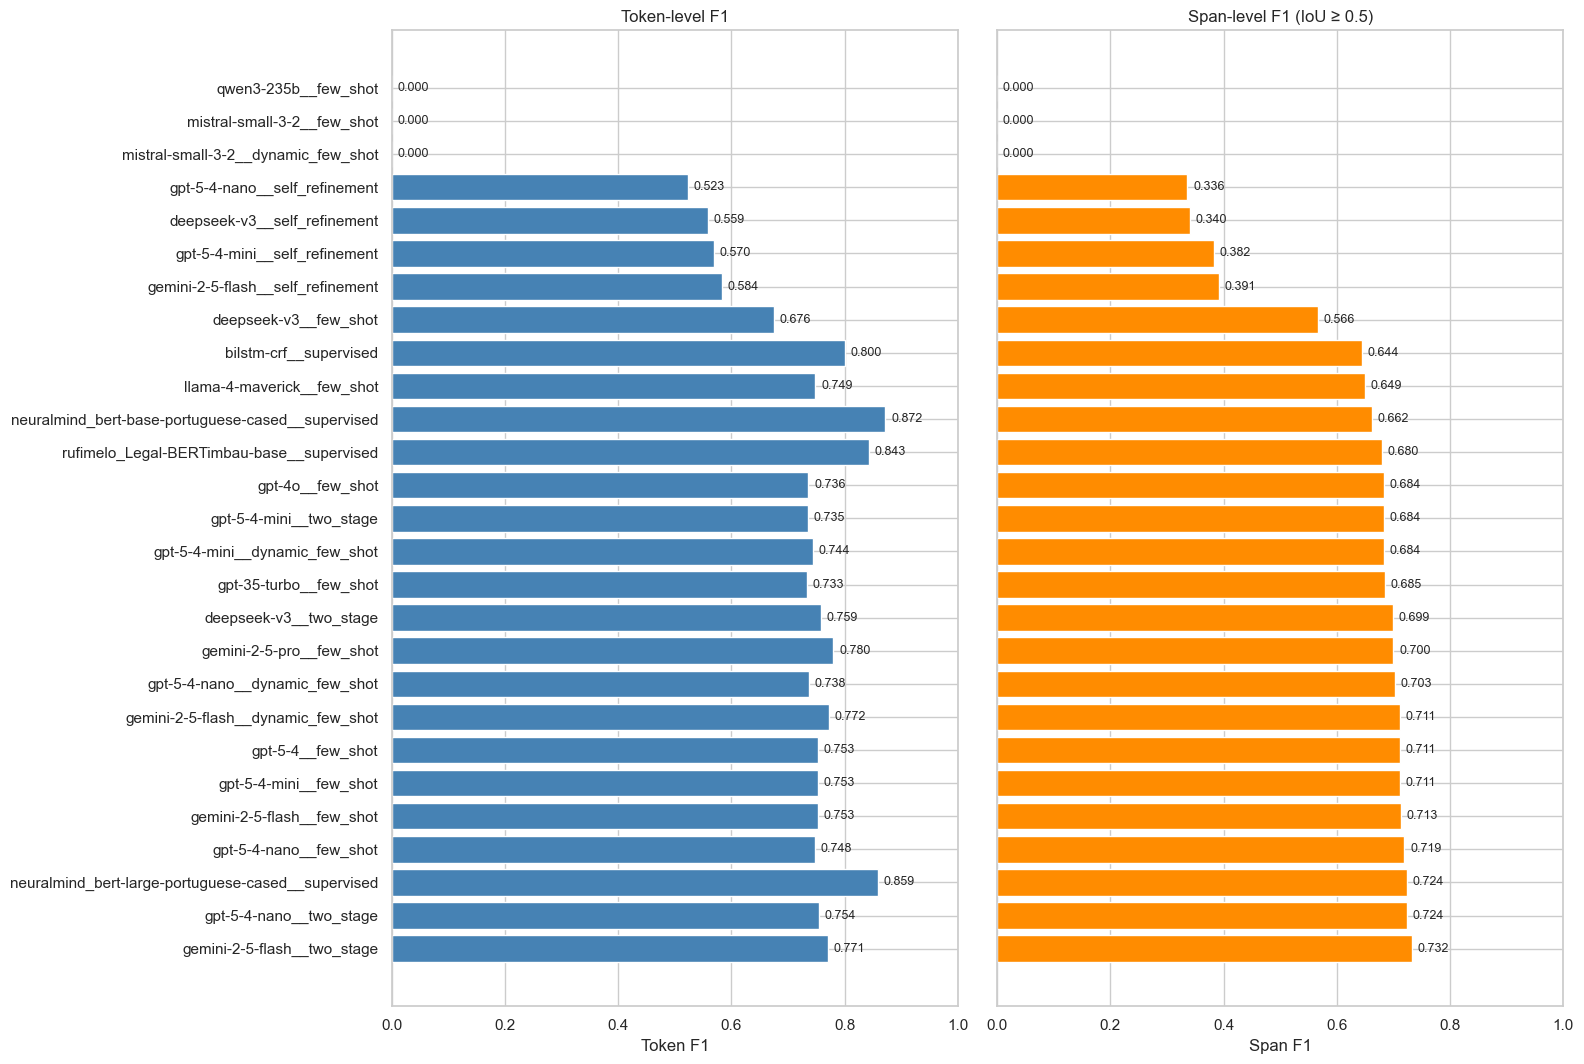

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(df_metrics) * 0.4)), sharey=True)

order = df_metrics.index.tolist()

axes[0].barh(order, df_metrics['token_f1'], color='steelblue')
axes[0].set_xlabel('Token F1')
axes[0].set_title('Token-level F1')
axes[0].set_xlim(0, 1)
for i, v in enumerate(df_metrics['token_f1']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

axes[1].barh(order, df_metrics['span_f1'], color='darkorange')
axes[1].set_xlabel('Span F1')
axes[1].set_title('Span-level F1 (IoU ≥ 0.5)')
axes[1].set_xlim(0, 1)
for i, v in enumerate(df_metrics['span_f1']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('overall_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Per-Entity Span F1 Heatmap

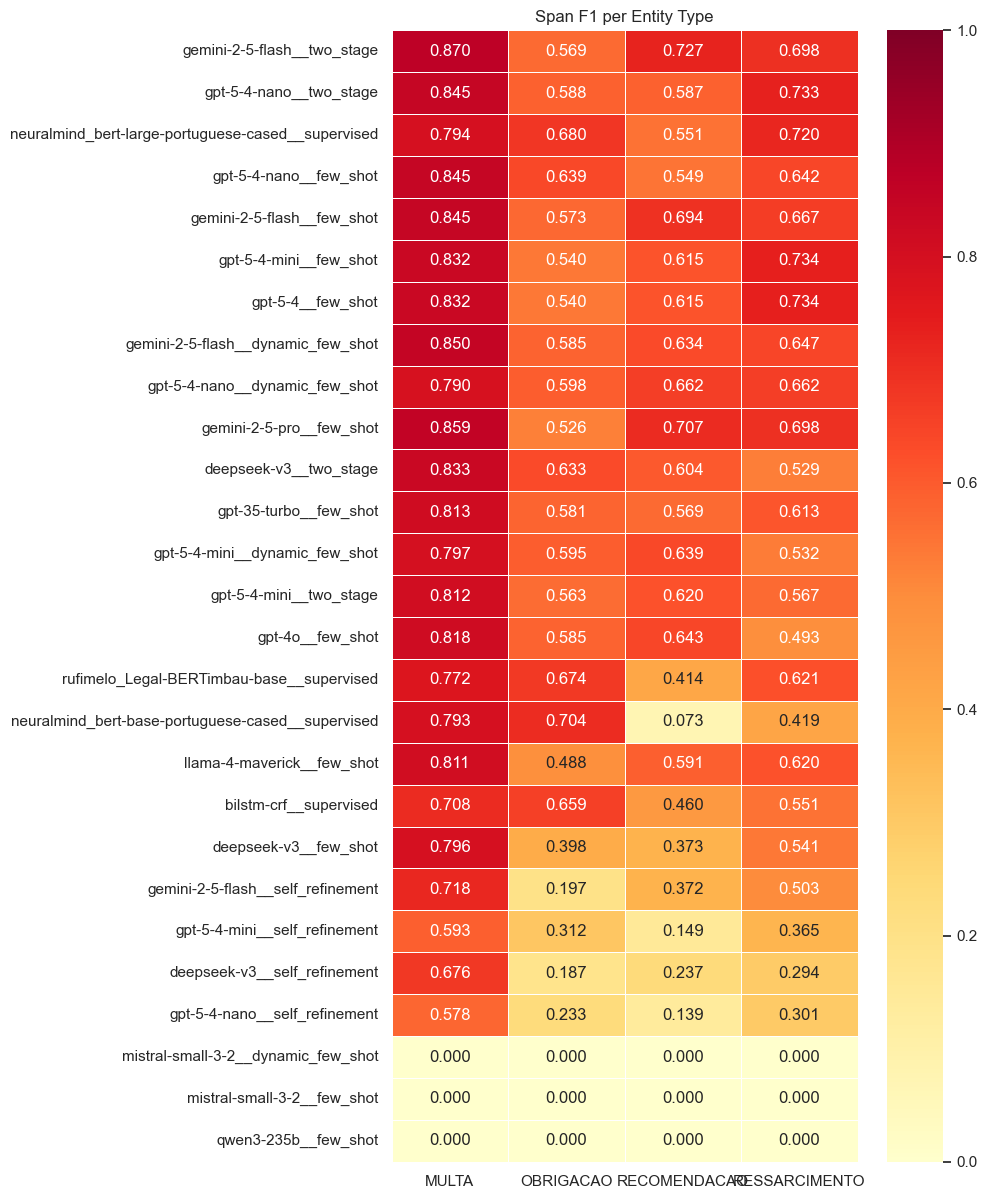

In [12]:
entity_labels = ['MULTA', 'OBRIGACAO', 'RECOMENDACAO', 'RESSARCIMENTO']
f1_cols = [f'f1_{l}' for l in entity_labels if f'f1_{l}' in df_metrics.columns]

df_entity = df_metrics[f1_cols].copy()
df_entity.columns = [c.replace('f1_', '') for c in df_entity.columns]

fig, ax = plt.subplots(figsize=(10, max(5, len(df_entity) * 0.45)))
sns.heatmap(df_entity, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, vmin=0, vmax=1)
ax.set_title('Span F1 per Entity Type')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('entity_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Strategy Comparison (grouped by strategy)

In [13]:
strategy_summary = df_metrics.groupby('strategy')[['token_f1', 'span_f1']].agg(['mean', 'std', 'max'])
strategy_summary.columns = ['_'.join(c) for c in strategy_summary.columns]
strategy_summary.sort_values('span_f1_mean', ascending=False, inplace=True)
display(strategy_summary.round(4))

,token_f1_mean,token_f1_std,token_f1_max,span_f1_mean,span_f1_std,span_f1_max
strategy,,,,,,
two_stage,0.7548,0.0149,0.7708,0.7097,0.0223,0.7318
supervised,0.8434,0.0312,0.8720,0.6775,0.0344,0.7241
few_shot,0.6073,0.3013,0.7803,0.5581,0.2793,0.7194
dynamic_few_shot,0.5634,0.3759,0.7719,0.5243,0.3497,0.7106
self_refinement,0.5587,0.0261,0.5836,0.3625,0.0284,0.3912


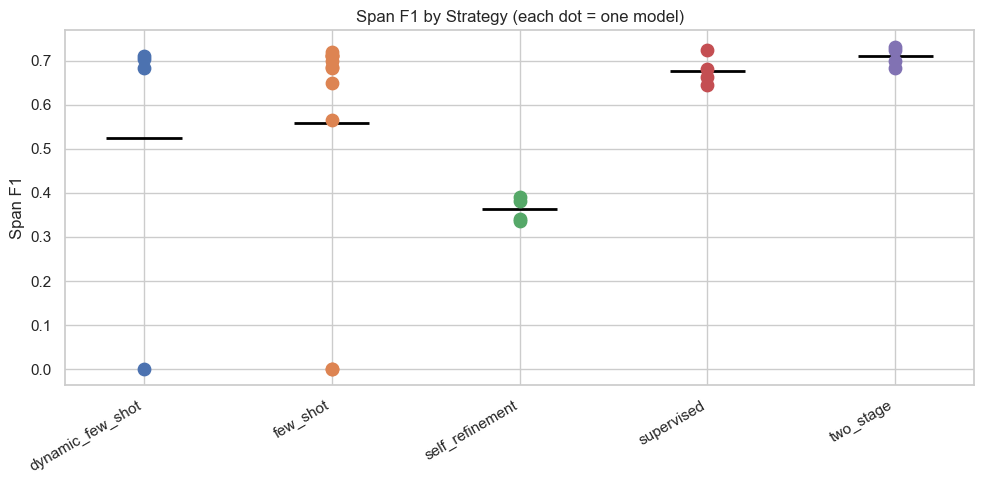

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
strategies = df_metrics['strategy'].unique()
x = np.arange(len(strategies))

for i, strat in enumerate(sorted(strategies)):
    subset = df_metrics[df_metrics['strategy'] == strat]
    ax.scatter([i]*len(subset), subset['span_f1'], s=80, zorder=5, label=strat if i < 10 else '')
    ax.hlines(subset['span_f1'].mean(), i-0.2, i+0.2, colors='black', linewidth=2)

ax.set_xticks(range(len(sorted(strategies))))
ax.set_xticklabels(sorted(strategies), rotation=30, ha='right')
ax.set_ylabel('Span F1')
ax.set_title('Span F1 by Strategy (each dot = one model)')
plt.tight_layout()
plt.savefig('strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Comparison (grouped by model)

In [15]:
model_summary = df_metrics.groupby('model')[['token_f1', 'span_f1']].agg(['mean', 'std', 'max'])
model_summary.columns = ['_'.join(c) for c in model_summary.columns]
model_summary.sort_values('span_f1_mean', ascending=False, inplace=True)
display(model_summary.round(4))

,token_f1_mean,token_f1_std,token_f1_max,span_f1_mean,span_f1_std,span_f1_max
model,,,,,,
neuralmind_bert-large-portuguese-cased,0.8587,NaN,0.8587,0.7241,NaN,0.7241
gpt-5-4,0.7526,NaN,0.7526,0.7107,NaN,0.7107
gemini-2-5-pro,0.7803,NaN,0.7803,0.7000,NaN,0.7000
gpt-35-turbo,0.7332,NaN,0.7332,0.6852,NaN,0.6852
gpt-4o,0.7362,NaN,0.7362,0.6836,NaN,0.6836
rufimelo_Legal-BERTimbau-base,0.8429,NaN,0.8429,0.6802,NaN,0.6802
neuralmind_bert-base-portuguese-cased,0.8720,NaN,0.8720,0.6617,NaN,0.6617
llama-4-maverick,0.7485,NaN,0.7485,0.6494,NaN,0.6494
bilstm-crf,0.8001,NaN,0.8001,0.6440,NaN,0.6440


## 8. Precision vs Recall Scatter

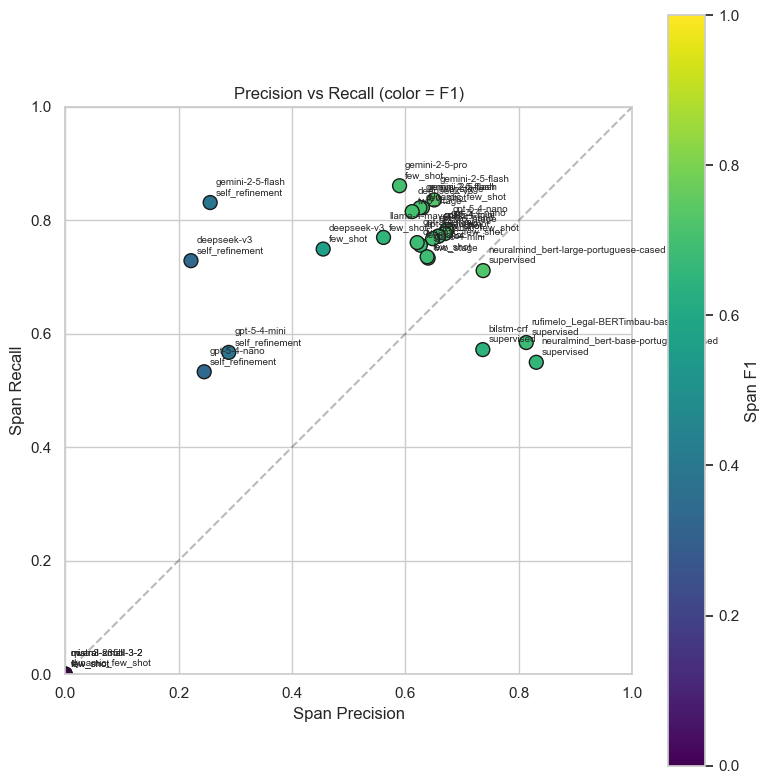

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(df_metrics['span_precision'], df_metrics['span_recall'],
           s=100, c=df_metrics['span_f1'], cmap='viridis', edgecolors='k', vmin=0, vmax=1)

for idx, row in df_metrics.iterrows():
    label = idx.replace('__', '\n')
    ax.annotate(label, (row['span_precision'], row['span_recall']),
                fontsize=7, ha='left', va='bottom', xytext=(4, 4),
                textcoords='offset points')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Span Precision')
ax.set_ylabel('Span Recall')
ax.set_title('Precision vs Recall (color = F1)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
plt.colorbar(ax.collections[0], ax=ax, label='Span F1')
plt.tight_layout()
plt.savefig('precision_recall_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Supervised vs LLM-based

In [17]:
df_metrics['paradigm'] = df_metrics['strategy'].apply(
    lambda s: 'supervised' if s in ('supervised', 'test') else 'llm-prompting')

paradigm_summary = df_metrics.groupby('paradigm')[['token_f1', 'span_f1']].agg(['mean', 'max'])
paradigm_summary.columns = ['_'.join(c) for c in paradigm_summary.columns]
display(paradigm_summary.round(4))

,token_f1_mean,token_f1_max,span_f1_mean,span_f1_max
paradigm,,,,
llm-prompting,0.6169,0.7803,0.5446,0.7318
supervised,0.8434,0.8720,0.6775,0.7241


## 10. Top-5 Experiments & Key Insights

In [18]:
print('=== TOP 5 by Span F1 ===')
display(df_metrics[['model', 'strategy', 'span_f1', 'token_f1']].head())

print('\n=== BEST per entity ===')
for label in entity_labels:
    col = f'f1_{label}'
    if col in df_metrics.columns:
        best_idx = df_metrics[col].idxmax()
        print(f'  {label}: {best_idx}  ({df_metrics.loc[best_idx, col]:.4f})')

print('\n=== BEST per strategy ===')
for strat in sorted(df_metrics['strategy'].unique()):
    subset = df_metrics[df_metrics['strategy'] == strat]
    best = subset['span_f1'].idxmax()
    print(f'  {strat}: {best}  (span_f1={subset.loc[best, "span_f1"]:.4f})')

=== TOP 5 by Span F1 ===


,model,strategy,span_f1,token_f1
experiment,,,,
gemini-2-5-flash__two_stage,gemini-2-5-flash,two_stage,0.731805,0.770809
gpt-5-4-nano__two_stage,gpt-5-4-nano,two_stage,0.724211,0.754475
neuralmind_bert-large-portuguese-cased__supervised,neuralmind_bert-large-portuguese-cased,supervised,0.724051,0.858748
gpt-5-4-nano__few_shot,gpt-5-4-nano,few_shot,0.719409,0.747873
gemini-2-5-flash__few_shot,gemini-2-5-flash,few_shot,0.713439,0.753329



=== BEST per entity ===
  MULTA: gemini-2-5-flash__two_stage  (0.8696)
  OBRIGACAO: neuralmind_bert-base-portuguese-cased__supervised  (0.7039)
  RECOMENDACAO: gemini-2-5-flash__two_stage  (0.7273)
  RESSARCIMENTO: gpt-5-4-mini__few_shot  (0.7344)

=== BEST per strategy ===
  dynamic_few_shot: gemini-2-5-flash__dynamic_few_shot  (span_f1=0.7106)
  few_shot: gpt-5-4-nano__few_shot  (span_f1=0.7194)
  self_refinement: gemini-2-5-flash__self_refinement  (span_f1=0.3912)
  supervised: neuralmind_bert-large-portuguese-cased__supervised  (span_f1=0.7241)
  two_stage: gemini-2-5-flash__two_stage  (span_f1=0.7318)


## 11. Export Summary

In [19]:
df_metrics.to_csv('ner_results_summary.csv')
print('Saved ner_results_summary.csv')

Saved ner_results_summary.csv
